### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### List of function

In [29]:
# function to normalize sgRNA LFC by median
def normalize_column(col):
    median = np.nanmedian(col)
    centered = col - median
    mad = np.nanmedian(np.abs(centered))
    if mad == 0 or np.isnan(mad):
        return centered
    return centered / mad

# function to scaled LFC by the absolute average LFC value across cell lines for guides targeting essential genes (Achilles Common Essential Controls)
def scale_essential(df):
    common_essential = pd.read_csv('AchillesCommonEssentialControls_25Q2.csv')
    common_essential[['gene', 'accession']] = common_essential['Gene'].str.split(' ', n = 1, expand = True)
    common_essential = common_essential[['gene', 'accession']]

    list_common_essential = list(common_essential['gene'])
    list_common_essential

    # subset guides targeting essential genes
    ess_guides = df.loc[df.index.get_level_values('gene').isin(list_common_essential)]

    # compute average LFC across cell lines for each essential guides
    ess_avg = ess_guides.mean(axis = 1)

    # take absolute value and average across guides
    scale_factor = np.mean(np.abs(ess_avg))
    print('Scale factor: ', scale_factor)

    df_scaled = df / scale_factor
    
    return df_scaled, list_common_essential

def sanity_check_scale_essential(df, df_scaled, list_common_essential):
    # Sanity check for the scaling LFC method
    ess_before = df.loc[df.index.get_level_values('gene').isin(list_common_essential)].stack().values
    ess_after = df_scaled.loc[df_scaled.index.get_level_values('gene').isin(list_common_essential)].stack().values

    plt.boxplot([ess_before, ess_after], labels = ['Before', 'After'])
    plt.ylabel('logFC guides targeting common essential genes')
    plt.show()
    
# function to correct LFC for gene copy number alterations 

# function to average the row of the spacer
def mean_row(df):
    df['mean'] = df.mean(axis = 1)
    df = df['mean']
    return df


#### Process Avana LFC and library data

In [30]:
lfc_data = pd.read_csv("AvanaLogfoldChange_25Q2.csv")
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})
lfc_data.head(25)

,spacer,Colo699-311cas9-RepA-p6_Avana-4,Colo699-311cas9-RepB-p6_Avana-4,HSB-2-311cas9_RepA_p4_Avana-3,HSB-2-311cas9_RepB_p4_Avana-3,NCIH1339-311Cas9_RepA_p6_Avana-3,NCIH1339-311Cas9_RepB_p6_Avana-3,HEL-311Cas9_RepA_p4_Avana-3,HEL-311Cas9_RepB_p4_Avana-3,HEL9217-311Cas9_RepA_p6_Avana-3,...,SNU977-311Cas9-AVANA-RepA-p6_Avana-4,SNU977-311Cas9-AVANA-RepB-p6_Avana-4,HMMME-311cas9-RepA-p6_Avana-4,HMMME-311cas9-RepB-p6_Avana-4,JVE528-311cas9-RepB-p6_Avana-4,UACC3133-311Cas9-RepB-P6_Avana-4,LU139-311cas9-RepB-p5_Avana-4,UPMM3-311cas9-RepA-p4_Avana-4,UACC3199-311cas9-RepA-p4_Avana-4,UACC3199-311cas9-RepB-p4_Avana-4
0,AAAAAAATCCAGCAATGCAG,-0.171066,0.029490,0.069540,0.162750,0.237938,0.229052,-0.173349,0.156643,0.107993,...,-0.433790,-0.709138,-0.580378,-0.268531,0.058415,-0.033800,-0.085320,-0.644091,-0.174569,-0.096824
1,AAAAAACCCGTAGATAGCCT,-0.402138,-0.307266,-0.313058,-0.433916,-0.572646,-0.556764,-0.705799,-0.314606,-0.209826,...,-0.563867,-0.484689,0.159082,-0.080677,-0.283203,-0.743975,-0.155078,-0.690596,-0.232494,-0.472361
2,AAAAAAGAAGAAAAAACCAG,-0.410449,-0.612478,-0.212222,0.136822,-0.588377,-0.974504,0.459130,0.696312,0.176283,...,-0.891883,-0.020638,-1.392148,-1.293585,-0.268365,0.607852,-1.211994,-0.030394,0.071135,-0.128212
3,AAAAAAGCTCAAGAAGGAGG,-0.391271,-0.523115,-0.747823,-0.443279,-0.652751,0.126859,-0.867980,-0.185511,0.051901,...,-0.501404,-0.422998,0.219032,-0.162117,-0.621547,0.068720,-0.918813,-0.843293,-0.216612,-0.447530
4,AAAAAAGGCTGTAAAAGCGT,-0.529545,-0.078421,-0.177395,-0.709120,-0.063580,-0.467151,0.234004,-0.271095,0.193193,...,-0.972852,-0.260724,0.118860,0.248156,-0.121191,0.053813,-0.300063,-0.188982,0.218309,0.120868
5,AAAAAAGGGCTCCAAAAAGG,-0.597079,0.196256,-0.442051,-0.489512,-0.207339,-0.239894,-0.875915,0.084434,-0.153561,...,-0.080975,-0.083456,-0.711989,-0.899371,0.318502,0.024631,-0.358011,-0.006433,0.467287,0.005282
6,AAAAACAACACATCAGAGCG,0.381416,-0.204037,-0.303099,-0.172987,0.136454,-0.488989,0.407917,0.625015,-0.043604,...,-1.471265,-0.578224,0.142722,0.101824,-0.295583,0.101226,0.830775,0.152045,0.135000,-0.275124
7,AAAAACTCTGGGAAATGACT,0.334391,0.231206,0.208982,-0.238882,-0.247617,0.030078,0.372719,0.573196,0.025043,...,-0.252516,0.023167,0.348881,0.520460,-0.340950,-0.240883,0.145043,0.258763,0.080839,-0.062581
8,AAAAAGACAACCTCGCCCTG,0.108744,0.099787,0.444292,0.007283,-0.231494,0.242598,-0.699215,0.081067,0.227647,...,-0.539427,0.338899,-0.554798,-0.266942,-0.016523,-0.214951,0.204190,-0.200871,-0.086072,-0.028628
9,AAAAAGAGCTGTTTGAACAA,-0.084525,0.066873,-0.253916,0.098424,0.055886,0.177427,0.056252,-0.018906,0.108850,...,0.447708,0.405770,0.034198,0.355359,-0.121250,0.173787,0.590183,0.087866,-0.021700,0.248652


In [31]:
library_data = pd.read_csv("../../CRISPR-KO-library-refinement-pipeline/public_crispr_library/avana_library.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
library_data.shape

(71826, 3)

In [32]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

Colo699-311cas9-RepA-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.257686   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.233408   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                         0.023756   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                         0.014280   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                         0.054652   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                         -0.347602   
         TTTTACCTTGTTCACATGGA NaN                          0.085937   
         TTTTGACTCTAATCACCGGT NaN                          0.004612   
         TTTTTAATACAAGGTAATCT NaN                         -0.007124   
         TTTTTCTCACCCGATGAATC NaN                          0.033292   

                                    Colo699-311cas9-RepB-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.298174   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.299895   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                        -0.473843   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                        -0.324734   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                        -0.087523   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                          0.320081   
         TTTTACCTTGTTCACATGGA NaN                          0.292619   
         TTTTGACTCTAATCACCGGT NaN                         -0.385894   
         TTTTTAATACAAGGTAATCT NaN                          0.154439   
         TTTTTCTCACCCGATGAATC NaN                         -0.138348   

                                    HSB-2-311cas9_RepA_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.226088   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.425173   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.419967   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                       0.235696   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.405659   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.042124   
         TTTTACCTTGTTCACATGGA NaN                        0.207097   
         TTTTGACTCTAATCACCGGT NaN                        0.182117   
         TTTTTAATACAAGGTAATCT NaN                       -0.221927   
         TTTTTCTCACCCGATGAATC NaN                       -0.256905   

                                    HSB-2-311cas9_RepB_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.030155   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.251597   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.159187   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                      -0.686056   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.322912   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.290717   
         TTTTACCTTGTTCACATGGA NaN                        0.210888   
         TTTTGACTCTAATCACCGGT NaN                        0.221753   
         TTTTTAATACAAGGTAATCT NaN                       -0.152003   
         TTTTTCTCACCCGATGAATC NaN                       -0.251676   

                                    NCIH1339-311Cas9_RepA_p6_Avana-3  \
sgRNA    spacer               gene                                     
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                          0.195384   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         -0.004233   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                          0.235672   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1

In [33]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  1.2376473275775624


/tmp/ipykernel_1041239/2939665036.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ess_before, ess_after], labels = ['Before', 'After'])


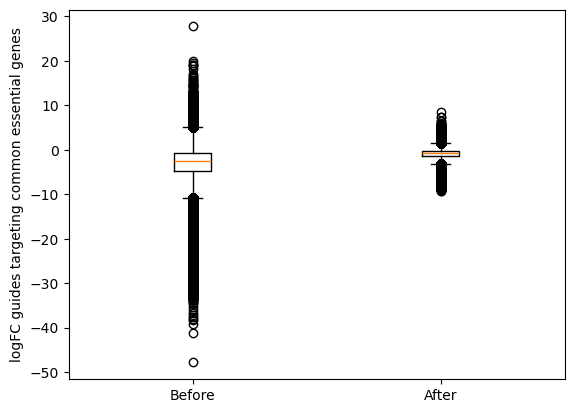

In [34]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc)
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)


In [35]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,0.000033
1,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.241808
2,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.089741
3,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,0.051367
4,sgA1CF_2,GGAATCAAATCACAAATCCG,A1CF,-0.096843
...,...,...,...,...
76422,NaN,TTTGTGTATTACCTCAGGAA,NaN,0.015253
76423,NaN,TTTTACCTTGTTCACATGGA,NaN,0.335777
76424,NaN,TTTTGACTCTAATCACCGGT,NaN,0.173447
76425,NaN,TTTTTAATACAAGGTAATCT,NaN,0.248071


In [36]:
lfc_norm_scaled_avg.to_csv("./normalized/avana_normalized_lfc.csv", index=False)

In [14]:
aln_data = pd.read_csv('avana_stratify_multi_target.csv')
aln_data = aln_data[['sgRNA', 'alignment_bin']]
aln_data = aln_data.astype(str)
aln_data

,sgRNA,alignment_bin
0,sgA1BG_1,1
1,sgA1BG_2,1
2,sgA1BG_3,1
3,sgA1BG_4,1
4,sgA1CF_1,1
...,...,...
72274,sgZZEF1_4,1
72275,sgZZZ3_1,1
72276,sgZZZ3_2,1
72277,sgZZZ3_3,1


In [15]:
final_data = pd.merge(lfc_norm_scaled_avg, aln_data, how="left", on="sgRNA").sort_values(by="gene")
final_data

,sgRNA,spacer,gene,mean,alignment_bin
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,0.000033,1
1,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,0.051411,1
2,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.242014,1
3,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.089817,1
4,sgA1CF_4,GGTGCAGCATCCCAACCAGG,A1CF,-0.006772,1
...,...,...,...,...,...
77889,NaN,TTTGTGACTTTAATACCAAA,NaN,0.276193,NaN
77890,NaN,TTTGTGCTCTAGGAGAAGAA,NaN,-0.130408,NaN
77891,NaN,TTTGTTACAAATCTTACAAA,NaN,0.184078,NaN
77892,NaN,TTTGTTCTGCCTAATTGAGG,NaN,0.110359,NaN


In [16]:
final_data.dropna()

,sgRNA,spacer,gene,mean,alignment_bin
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,0.000033,1
1,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,0.051411,1
2,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.242014,1
3,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.089817,1
4,sgA1CF_4,GGTGCAGCATCCCAACCAGG,A1CF,-0.006772,1
...,...,...,...,...,...
74167,sgZZEF1_3,GGCCGGCTCCAGCAGCGCCG,ZZEF1,-0.247544,1
74171,sgZZZ3_2,AGATGGTTCAGGTTCTCCGG,ZZZ3,-1.040494,1
74172,sgZZZ3_4,GCAGTAGTTGAAGAAATCAC,ZZZ3,-0.338580,1
74170,sgZZZ3_3,GAGCCTGTGCCAATTCAGAA,ZZZ3,0.179613,1


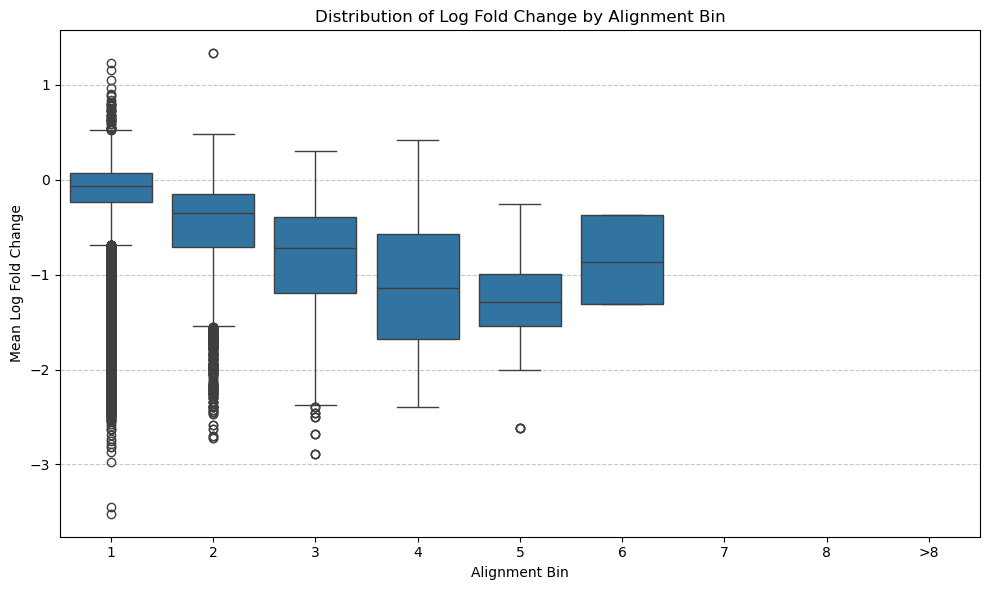

Statistics by alignment bin:
                 count      mean       std       min       25%       50%  \
alignment_bin                                                              
1              67141.0 -0.156557  0.389165 -3.519379 -0.236362 -0.061329   
2               3907.0 -0.500622  0.546690 -2.717216 -0.705796 -0.352817   
3                740.0 -0.824950  0.616921 -2.886450 -1.192459 -0.715127   
4                331.0 -1.107827  0.676012 -2.391202 -1.680281 -1.145517   
5                110.0 -1.280801  0.506204 -2.614192 -1.537727 -1.293735   
6                 14.0 -0.846779  0.419611 -1.308730 -1.308730 -0.862066   
7                  0.0       NaN       NaN       NaN       NaN       NaN   
8                  0.0       NaN       NaN       NaN       NaN       NaN   
>8                 0.0       NaN       NaN       NaN       NaN       NaN   

                    75%       max  
alignment_bin                      
1              0.067351  1.226752  
2             -0.145442  1

/tmp/ipykernel_1041239/3071709042.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_data.groupby('alignment_bin')['mean'].describe())


In [17]:
# Merge final_data (which has the mean values) with aln_data (which has alignment_bin)
plot_data = final_data[['sgRNA', 'gene', 'mean']].merge(aln_data, on='sgRNA', how='inner')

# Define the desired order
order = ['1', '2', '3', '4', '5', '6', '7', '8', '>8']

# Make alignment_bin a categorical variable with this order
plot_data['alignment_bin'] = pd.Categorical(plot_data['alignment_bin'], 
                                            categories=order, 
                                            ordered=True)

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='alignment_bin', y='mean', data=plot_data)
# sns.stripplot(x='alignment_bin', y='mean', data=plot_data, size=2, color='black', alpha=0.3)

plt.title('Distribution of Log Fold Change by Alignment Bin')
plt.xlabel('Alignment Bin')
plt.ylabel('Mean Log Fold Change')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display some statistics
print("Statistics by alignment bin:")
print(plot_data.groupby('alignment_bin')['mean'].describe())